In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [2]:
# Create a simple dataset
data = pd.DataFrame({
    'Size_sqft': [1000, 1500, 2000, 1200, 1800, 1600, 1400],
    'Bedrooms': [2, 3, 4, 2, 3, 3, 2],
    'Age_years': [10, 5, 2, 8, 4, 6, 9],
    'Price_lakh': [50, 70, 90, 55, 80, 75, 60]
})


In [3]:
X = data[['Size_sqft', 'Bedrooms', 'Age_years']]
y = data['Price_lakh']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [5]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [6]:
y_pred = model.predict(X_test)

print("Intercept:", model.intercept_)
print("Coefficients:", dict(zip(X.columns, model.coef_)))
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


Intercept: 24.99999999999997
Coefficients: {'Size_sqft': 0.03125000000000004, 'Bedrooms': 1.2499999999999898, 'Age_years': -1.2500000000000013}
R² Score: 0.9185267857142853
RMSE: 3.0830517889476634


In [10]:
# New house: 1700 sqft, 3 bedrooms, 5 years old
new_house = pd.DataFrame([[1500, 3, 5]], columns=X.columns)
model.predict(new_house)
print("Predicted Price (₹ lakh):", predicted_price[0])


Predicted Price (₹ lakh): 75.625


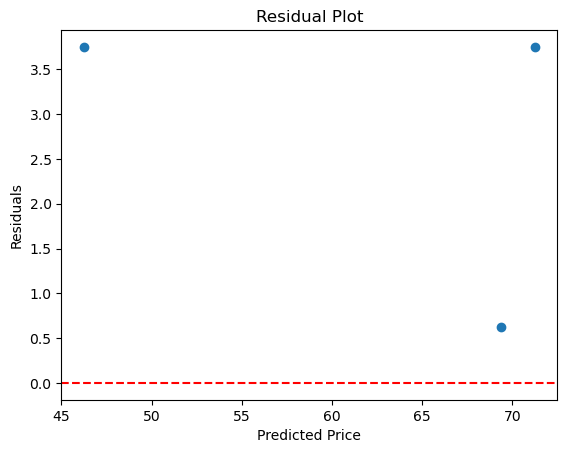

In [11]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()
